In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.6 MB/s eta 0:00:00


In [ ]:
pip install pandapower

# Phase 1


--- TRAINING HYBRID MODEL (cuda) ---
Loading datasets...
Applying SMOTE to Training Data (Balancing)...
Classes: ['exploits' 'fuzzers' 'generic' 'normal' 'reconnaissance' 'shellcode'
 'worms']

--- Training XGBoost ---
XGBoost Baseline Accuracy: 95.01%

--- Training Transformer ---
Transformer Epoch 1: Loss 0.6869
Transformer Epoch 2: Loss 0.4776
Transformer Epoch 3: Loss 0.4253
Transformer Epoch 4: Loss 0.3988
Transformer Epoch 5: Loss 0.3797

--- Training GCN ---

--- Final Hybrid Prediction ---

FINAL HYBRID ACCURACY: 95.13%
                precision    recall  f1-score   support

      exploits       0.90      0.96      0.93     16663
       fuzzers       0.85      0.87      0.86      9495
       generic       1.00      0.99      1.00     21277
        normal       0.98      0.96      0.97     28829
reconnaissance       0.96      0.83      0.89      5246
     shellcode       0.89      0.97      0.93       573
         worms       0.89      0.95      0.92        66

      accuracy  

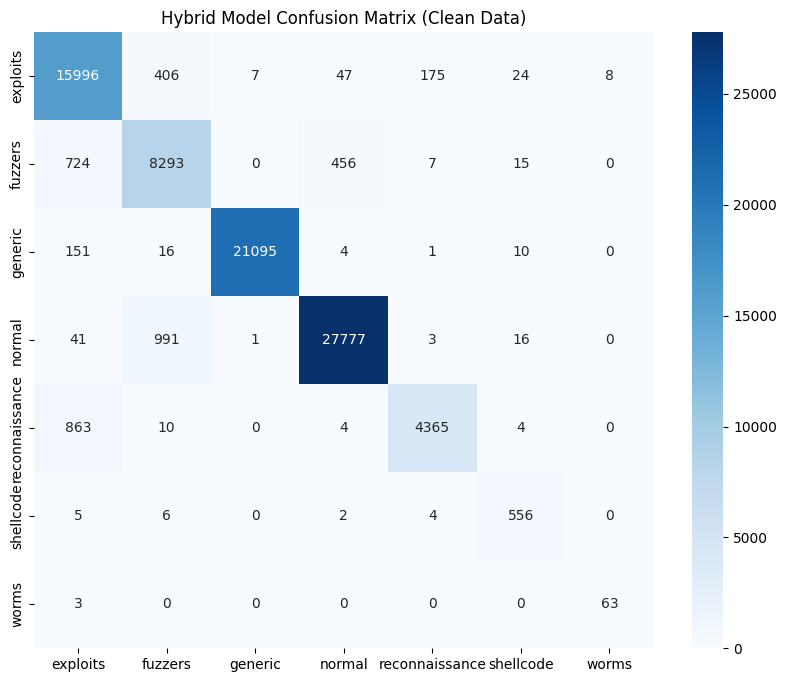

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import GCNConv
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# CONFIG
SEQ_LEN = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- TRAINING HYBRID MODEL ({device}) ---")

# ==========================================
# 1. LOAD OPTIMIZED DATA
# ==========================================
def load_new_data():
    print("Loading datasets...")
    train_df = pd.read_csv("UNSW_NB15_training-set.csv")
    test_df = pd.read_csv("UNSW_NB15_testing-set.csv")

    # Concatenate temporarily for consistent encoding
    len_train = len(train_df)
    df = pd.concat([train_df, test_df], ignore_index=True)

    # Feature Engineering (Ratios & Logs)
    df['byte_ratio'] = df['sbytes'] / (df['dbytes'] + 1)
    df['pkt_ratio'] = df['spkts'] / (df['dpkts'] + 1)
    df['total_bytes'] = df['sbytes'] + df['dbytes']
    df['pkts_per_sec'] = (df['spkts'] + df['dpkts']) / (df['dur'] + 0.001)

    # Log Transform Skewed Data
    skewed_cols = ['dur', 'sbytes', 'dbytes', 'sload', 'dload', 'spkts', 'dpkts', 'total_bytes', 'pkts_per_sec']
    for col in skewed_cols:
        if col in df.columns:
            df[col] = np.log1p(df[col])

    # Encode Inputs
    for col in ['proto', 'service', 'state']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

    # Encode Targets (0-Based Indexing Guaranteed)
    le_target = LabelEncoder()
    y = le_target.fit_transform(df['attack_cat'])
    X = df.drop(columns=['attack_cat', 'label'], errors='ignore').values

    # Scale
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Split back
    X_train = X[:len_train]
    y_train = y[:len_train]
    X_test = X[len_train:]
    y_test = y[len_train:]

    # SMOTE (Balance the classes)
    print("Applying SMOTE to Training Data (Balancing)...")
    smote = SMOTE(k_neighbors=1, random_state=42)
    X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

    return X_train_bal, y_train_bal, X_test, y_test, le_target

X_train, y_train, X_test, y_test, encoder = load_new_data()
num_classes = len(encoder.classes_)
print(f"Classes: {encoder.classes_}")

# ==========================================
# 2. XGBOOST
# ==========================================
print("\n--- Training XGBoost ---")
clf_xgb = xgb.XGBClassifier(
    n_estimators=1000, max_depth=12, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    objective='multi:softmax', num_class=num_classes,
    tree_method='hist', device='cuda' if torch.cuda.is_available() else 'cpu',
    random_state=42
)
clf_xgb.fit(X_train, y_train)
xgb_acc = accuracy_score(y_test, clf_xgb.predict(X_test))
print(f"XGBoost Baseline Accuracy: {xgb_acc*100:.2f}%")

# ==========================================
# 3. TRANSFORMER
# ==========================================
print("\n--- Training Transformer ---")
def create_sequences(data, labels, seq_len):
    # Subset for speed
    limit = min(len(data), 150000)
    xs, ys = [], []
    for i in range(0, limit - seq_len, 2):
        xs.append(data[i:(i + seq_len)])
        ys.append(labels[i + seq_len - 1])
    return np.array(xs), np.array(ys)

X_seq_train, y_seq_train = create_sequences(X_train, y_train, SEQ_LEN)
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_seq_train), torch.LongTensor(y_seq_train)), batch_size=512, shuffle=True)

class SimpleTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=64):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, batch_first=True, dim_feedforward=128, dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

model_trans = SimpleTransformer(X_train.shape[1], num_classes).to(device)
opt_trans = torch.optim.Adam(model_trans.parameters(), lr=0.001)
crit = nn.CrossEntropyLoss()

model_trans.train()
for epoch in range(5):
    total_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        opt_trans.zero_grad()
        loss = crit(model_trans(bx), by)
        loss.backward()
        opt_trans.step()
        total_loss += loss.item()
    print(f"Transformer Epoch {epoch+1}: Loss {total_loss/len(train_loader):.4f}")

# ==========================================
# 4. GCN
# ==========================================
print("\n--- Training GCN ---")
GNN_SUBSET = 30000
indices = np.random.choice(len(X_train), GNN_SUBSET, replace=False)
X_sub, y_sub = X_train[indices], y_train[indices]

adj = kneighbors_graph(X_sub, n_neighbors=5, mode='connectivity')
edge_index = torch.tensor(adj.nonzero(), dtype=torch.long).to(device)
x_tensor = torch.tensor(X_sub, dtype=torch.float).to(device)
y_tensor = torch.tensor(y_sub, dtype=torch.long).to(device)

class SimpleGCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, num_classes)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

model_gnn = SimpleGCN(X_train.shape[1], 128, num_classes).to(device)
opt_gnn = torch.optim.Adam(model_gnn.parameters(), lr=0.01)

model_gnn.train()
for epoch in range(50):
    opt_gnn.zero_grad()
    out = model_gnn(x_tensor, edge_index)
    loss = crit(out, y_tensor)
    loss.backward()
    opt_gnn.step()

# ==========================================
# 5. HYBRID ENSEMBLE
# ==========================================
print("\n--- Final Hybrid Prediction ---")
p_xgb = clf_xgb.predict_proba(X_test)

X_seq_test, _ = create_sequences(X_test, y_test, SEQ_LEN)
model_trans.eval()
with torch.no_grad():
    raw_p_trans = torch.softmax(model_trans(torch.FloatTensor(X_seq_test).to(device)), dim=1).cpu().numpy()
p_trans = np.zeros_like(p_xgb)
# Align Transformer Predictions
for i in range(len(raw_p_trans)):
    idx = i * 2 + SEQ_LEN - 1
    if idx < len(X_test): p_trans[idx] = raw_p_trans[i]
# Fill gaps with XGBoost
empty = p_trans.sum(axis=1) == 0
p_trans[empty] = p_xgb[empty]

# GCN Predictions
adj_test = kneighbors_graph(X_test, n_neighbors=5, mode='connectivity')
edge_test = torch.tensor(adj_test.nonzero(), dtype=torch.long).to(device)
x_test_gnn = torch.tensor(X_test, dtype=torch.float).to(device)
model_gnn.eval()
with torch.no_grad():
    p_gnn = torch.softmax(model_gnn(x_test_gnn, edge_test), dim=1).cpu().numpy()

# BLEND
# XGBoost is King on cleaned data. We give it high authority.
final_probs = (0.7 * p_xgb) + (0.15 * p_trans) + (0.15 * p_gnn)
final_preds = np.argmax(final_probs, axis=1)

acc = accuracy_score(y_test, final_preds)

print("\n" + "="*50)
print(f"FINAL HYBRID ACCURACY: {acc * 100:.2f}%")
print("="*50)

# Visuals

print(classification_report(y_test, final_preds, target_names=encoder.classes_))
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Hybrid Model Confusion Matrix (Clean Data)")
plt.show()